In [3]:
import pandas as pd

df = pd.read_parquet("all_images_8.parquet")

print(df.head())
print(df.shape)

                                               image  \
0  /data/test_images/2022_02_02 5nm Ag nanopartic...   
1  /data/test_images/2022_02_02 5nm Ag nanopartic...   
2  /data/test_images/2022_02_02 5nm Ag nanopartic...   
3  /data/test_images/2022_02_02 5nm Ag nanopartic...   
4  /data/test_images/2022_02_02 5nm Ag nanopartic...   

                                           clustered  
0  [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...  
1  [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, ...  
2  [0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...  
3  [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, ...  
4  [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, ...  
(13, 2)


In [4]:
import glob
import os
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.cluster import KMeans
from skimage.util import view_as_windows
import numpy as np
from persim import PersistenceImager
from ripser import lower_star_img
import pandas as pd
from itertools import islice

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def get_positions(image_data, patch_size=64, stride=16):
    if stride is None:
        stride = patch_size

    blocks = view_as_windows(
        image_data,
        (patch_size, patch_size),
        step=stride
    )

    n_rows, n_cols = blocks.shape[:2]

    positions = [
        (i * stride, j * stride)
        for i in range(n_rows)
        for j in range(n_cols)
    ]

    return positions

def label_to_image(original_image, labels, positions, patch_size=64):
    H, W = original_image.shape[:2]

    label_img = np.zeros((H, W), dtype=np.uint8)
    vote_img  = np.zeros((H, W), dtype=np.uint8)

    for (r, c), lab in zip(positions, labels):
        r_end = min(r + patch_size, H)
        c_end = min(c + patch_size, W)

        region = (slice(r, r_end), slice(c, c_end))

        votes = vote_img[region] + 1

        mask = votes >= vote_img[region]

        label_patch = label_img[region]
        label_patch[mask] = lab

        vote_img[region][mask] = votes[mask]

    return label_img

In [29]:
import numpy as np
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes
from skimage.morphology import binary_closing, disk
from pathlib import Path

image_dir = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/")
labels_dir = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/Labels")

output = Path("./cluster_results")


for id, row in df.iterrows():

    image_name = Path(row["image"]).stem
    out_dir = output / image_name
    out_dir.mkdir(parents=True, exist_ok=True)  

    matches = list(image_dir.glob(f"{image_name}.dm3"))
    truths = list(labels_dir.glob(f"{image_name}_label.png"))

    if not matches:
        continue

    image_path = matches[0]
    truth_path = truths[0]
    data_dict = dm.dmReader(str(Path(image_path).resolve()))
    original_image = data_dict['data']
    truth_img = mpimg.imread(truth_path).astype(np.uint8)

    labels = row["clustered"]
    positions = get_positions(original_image, 64, 16)
    label_img = label_to_image(original_image, row["clustered"], positions)
    output_path = out_dir / "labelimg.png"

   # plt.imsave(output_path, label_img, cmap="tab20")

    clusters = [0,1,2,3,4,5,6,7]

    for i in clusters:

        pred_mask  = (label_img == i)        
        truth_mask = (truth_img > 0)  

        clean_mask = remove_small_objects(pred_mask, max_size=100)
        clean_mask = binary_fill_holes(clean_mask)
        clean_mask = binary_closing(clean_mask, footprint=disk(2))
        clean_mask = remove_small_objects(clean_mask, max_size=1600)

        intersection = (clean_mask & truth_mask).sum()
        union        = (clean_mask | truth_mask).sum()

        iou  = intersection / union                              

        print(f"Image {str(image_name)} Cluster {i} — IoU: {iou:.3f} ")

        #plt.imsave(out_dir / f"cluster_{i}.png", mask, cmap="tab20")



/tmp/ipykernel_805888/3605568842.py:47: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_08 Cluster 0 — IoU: 0.014 


/tmp/ipykernel_805888/3605568842.py:47: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_08 Cluster 1 — IoU: 0.035 


/tmp/ipykernel_805888/3605568842.py:47: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


...

Image 20220202_Ag_UTC_330kx_2650e_0p1596s_11 Cluster 5 — IoU: 0.012 


/tmp/ipykernel_805888/3605568842.py:47: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_11 Cluster 6 — IoU: 0.017 


/tmp/ipykernel_805888/3605568842.py:47: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_11 Cluster 7 — IoU: 0.013 


Raw masks
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_08 Cluster 4 — IoU: 0.174 
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_05 Cluster 7 — IoU: 0.248 
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_07 Cluster 2 — IoU: 0.103 
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_03 Cluster 6 — IoU: 0.392 
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_02 Cluster 1 — IoU: 0.347 
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_10 Cluster 1 — IoU: 0.276 
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_13 Cluster 1 — IoU: 0.318 
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_12 Cluster 6 — IoU: 0.374 
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_14 Cluster 1 — IoU: 0.225 
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_09 Cluster 2 — IoU: 0.245 
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_04 Cluster 3 — IoU: 0.300 
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_06 Cluster 2 — IoU: 0.267 
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_11 Cluster 4 — IoU: 0.288

Cleaned masks:
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_08 Cluster 4 — IoU: 0.191 (+ 0.017)
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_05 Cluster 7 — IoU: 0.272 (+ 0.024)
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_07 Cluster 2 — IoU: 0.101 (- 0.002)
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_03 Cluster 6 — IoU: 0.392 (=)
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_02 Cluster 1 — IoU: 0.354 (+ 0.007)
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_10 Cluster 1 — IoU: 0.291 (+ 0.015)
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_13 Cluster 1 — IoU: 0.331 (+ 0.013)
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_12 Cluster 6 — IoU: 0.378 (+ 0.004)
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_14 Cluster 1 — IoU: 0.230 (+ 0.005)
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_09 Cluster 2 — IoU: 0.276 (+ 0.031)
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_04 Cluster 3 — IoU: 0.332 (+ 0.032)
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_06 Cluster 2 — IoU: 0.277 (+ 0.010)
Image 20220202_Ag_UTC_330kx_2650e_0p1596s_11 Cluster 4 — IoU: 0.321 (+ 0.033)

In [15]:
import pandas as pd

df = pd.read_parquet("density_analysis.parquet")

print(df.head())
print(df.shape)

                                    image  \
0  20220202_Ag_UTC_330kx_2650e_0p1596s_08   
1  20220202_Ag_UTC_330kx_2650e_0p1596s_05   
2  20220202_Ag_UTC_330kx_2650e_0p1596s_07   
3  20220202_Ag_UTC_330kx_2650e_0p1596s_03   
4  20220202_Ag_UTC_330kx_2650e_0p1596s_02   

                                   cluster_summaries  
0  {'0': [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...  
1  {'0': [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...  
2  {'0': [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...  
3  {'0': [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...  
4  {'0': [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...  
(13, 2)


In [23]:
print(type(long_df["pi"].iloc[0]))
print(np.array(long_df["pi"].iloc[0]).dtype)
print(np.array(long_df["pi"].iloc[0]).shape)

<class 'numpy.ndarray'>
object
(55,)


In [38]:
import numpy as np

print("vector lengths:", [len(v) for v in pi_vectors[:10]])
print("example norm:", np.linalg.norm(pi_vectors[0]))
print("min/max length:", min(len(v) for v in pi_vectors), max(len(v) for v in pi_vectors))

vector lengths: [2310, 2310, 2310, 2310, 2310, 2310, 2310, 2310, 2709, 2709]
example norm: 1209.2404050197997
min/max length: 2145 2880


In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from sklearn.metrics import pairwise_distances
import umap

# ----------------------------
# 1. LOAD PERSISTENCE IMAGES AS 2D GRIDS
# ----------------------------
pis = []
meta = []

for _, row in df.iterrows():
    img = row["image"]

    for c_id, pi in row["cluster_summaries"].items():
        v = np.array(pi, dtype=float)

        # assume PI is square-ish → reshape safely if needed
        size = int(np.sqrt(len(v)))
        pi2d = v[:size*size].reshape(size, size)

        pis.append(pi2d)
        meta.append((img, int(c_id)))

meta = np.array(meta)
images = meta[:, 0]
cluster_ids = meta[:, 1]

# ----------------------------
# 2. MULTI-SCALE SMOOTHING (KEY STEP)
# ----------------------------
def features(pi):
    f = []
    for sigma in [0.5, 1.0, 2.0]:
        sm = gaussian_filter(pi, sigma=sigma)
        f.append(sm.flatten())
    return np.concatenate(f)

X = np.vstack([features(pi) for pi in pis])

# ----------------------------
# 3. NORMALISE
# ----------------------------
X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)

# ----------------------------
# 4. DISTANCE IN FEATURE SPACE
# ----------------------------
D = pairwise_distances(X, metric="cosine")

# ----------------------------
# 5. EMBEDDING
# ----------------------------
emb = umap.UMAP(
    metric="precomputed",
    n_neighbors=12,
    min_dist=0.2,
    random_state=42
).fit_transform(D)

# ----------------------------
# 6. PLOT (WHAT YOU WANT)
# ----------------------------
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=emb[:, 0],
    y=emb[:, 1],
    hue=images,
    palette="tab20",
    s=60,
    legend=False
)

for i in range(len(emb)):
    plt.text(
        emb[i, 0],
        emb[i, 1],
        str(cluster_ids[i]),
        fontsize=7,
        alpha=0.7
    )

plt.title("Topology-aware PI similarity space (multi-scale)")
plt.show()

ValueError: setting an array element with a sequence.

/tmp/ipykernel_67142/3543555918.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


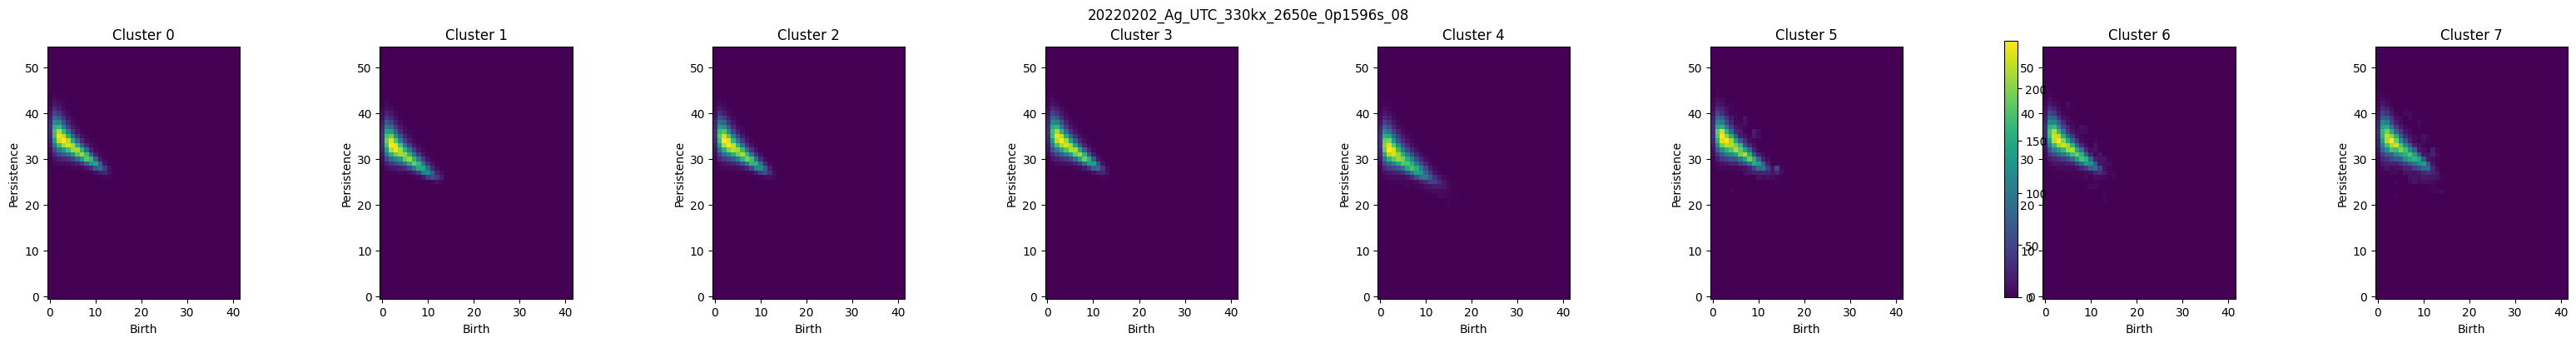

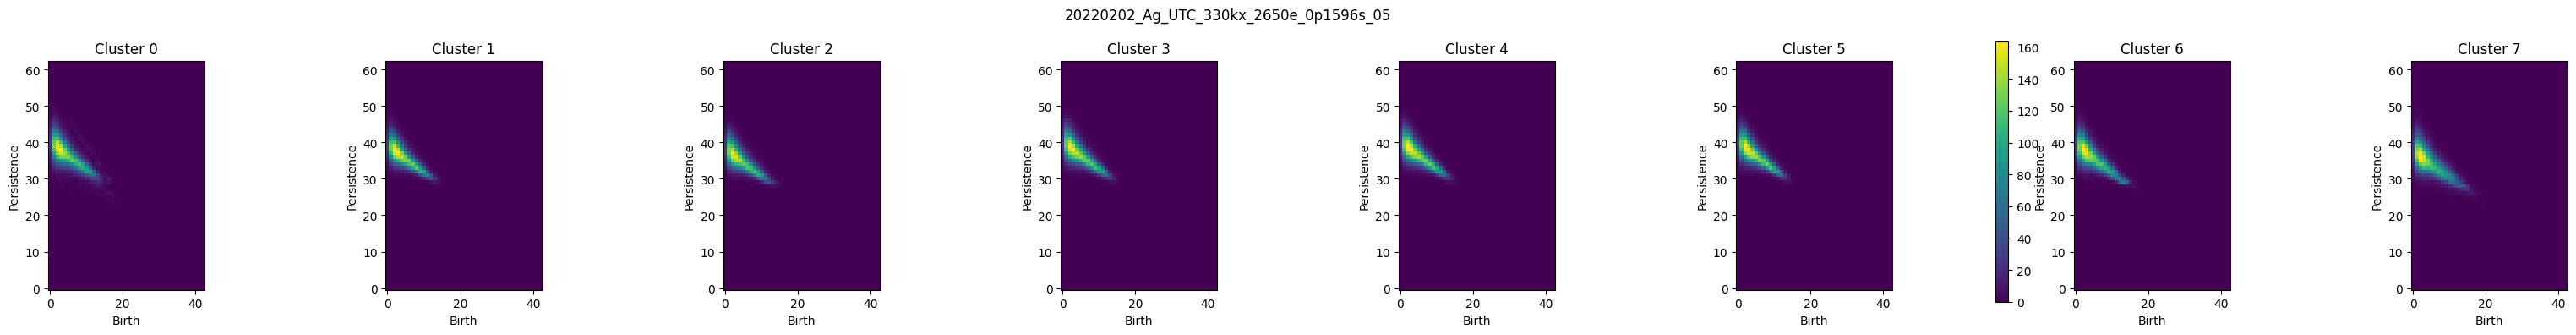

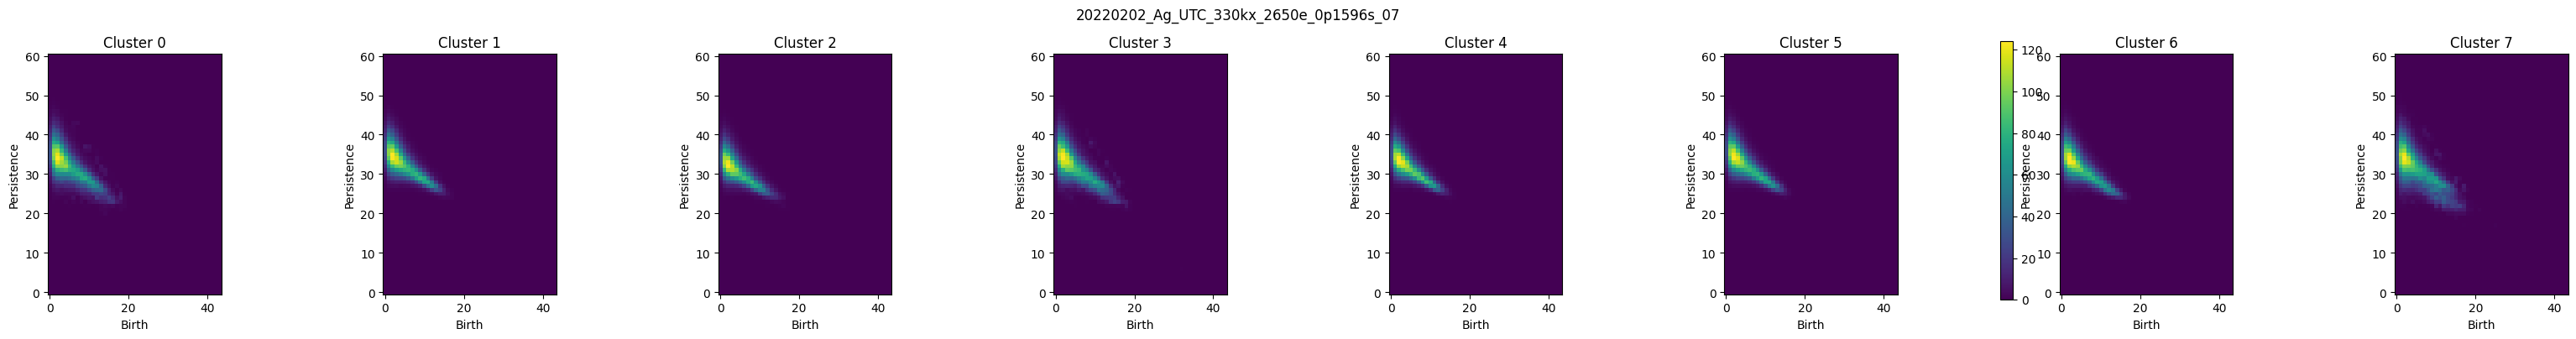

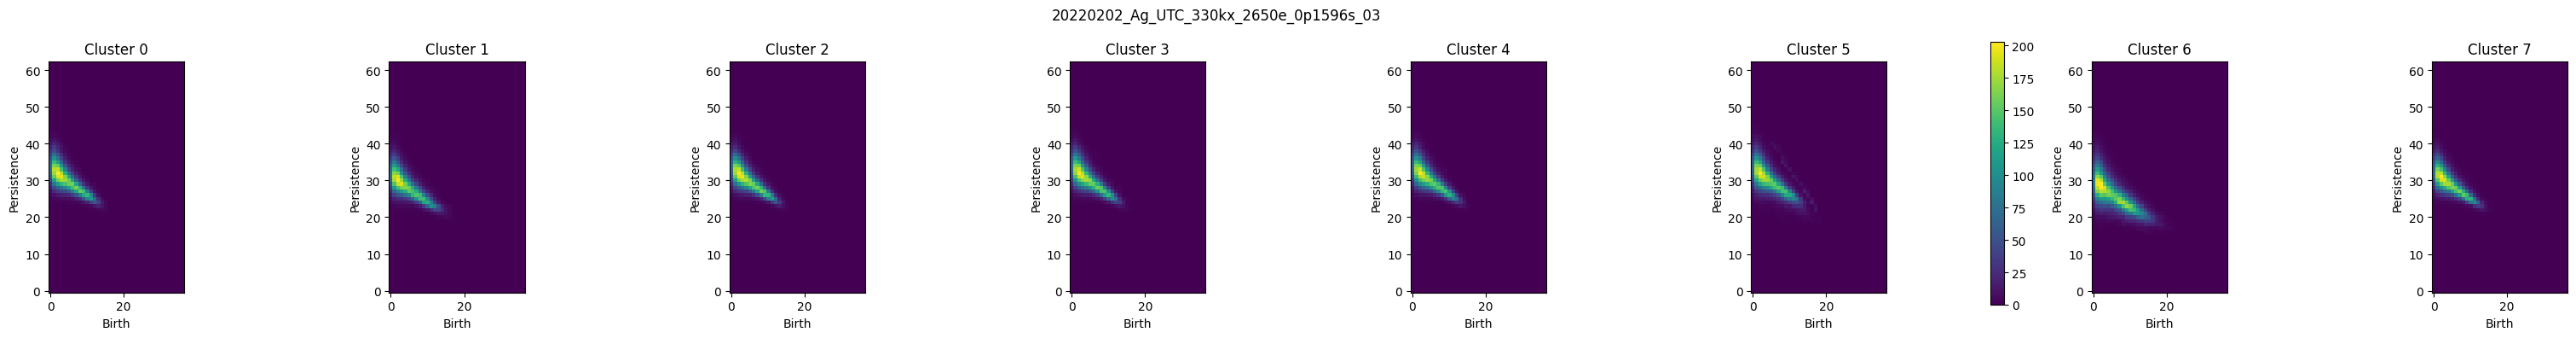

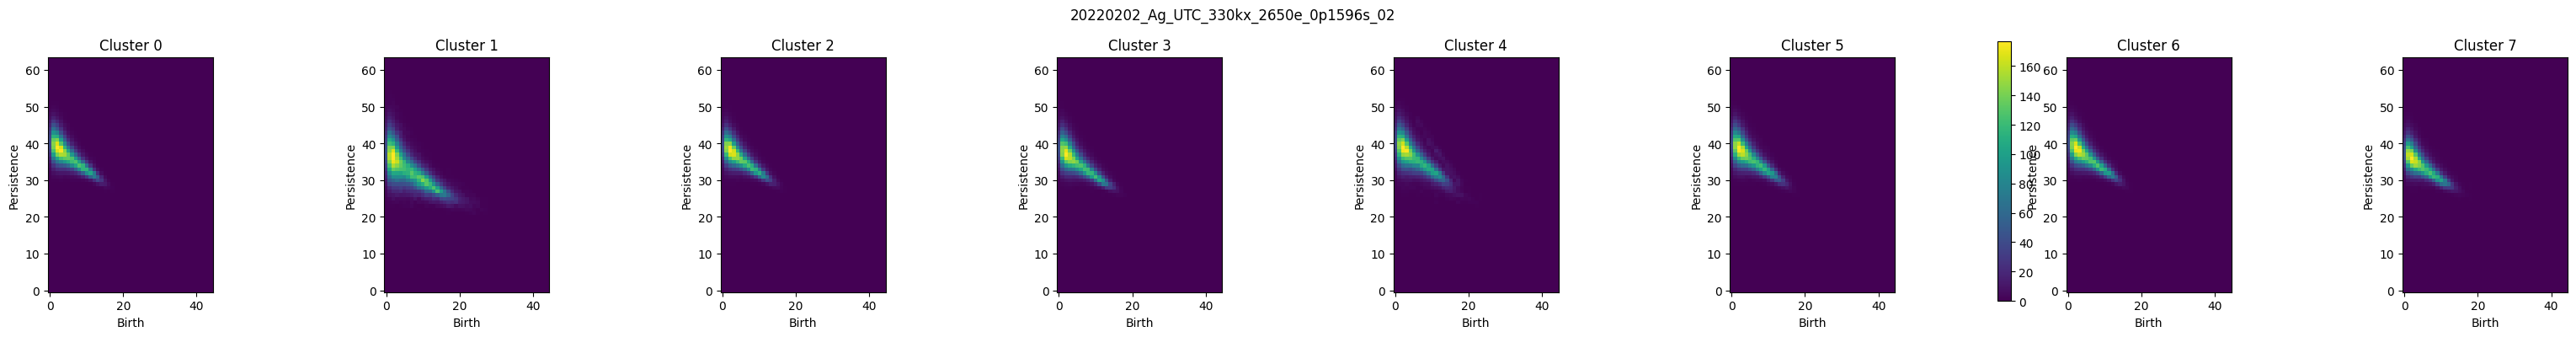

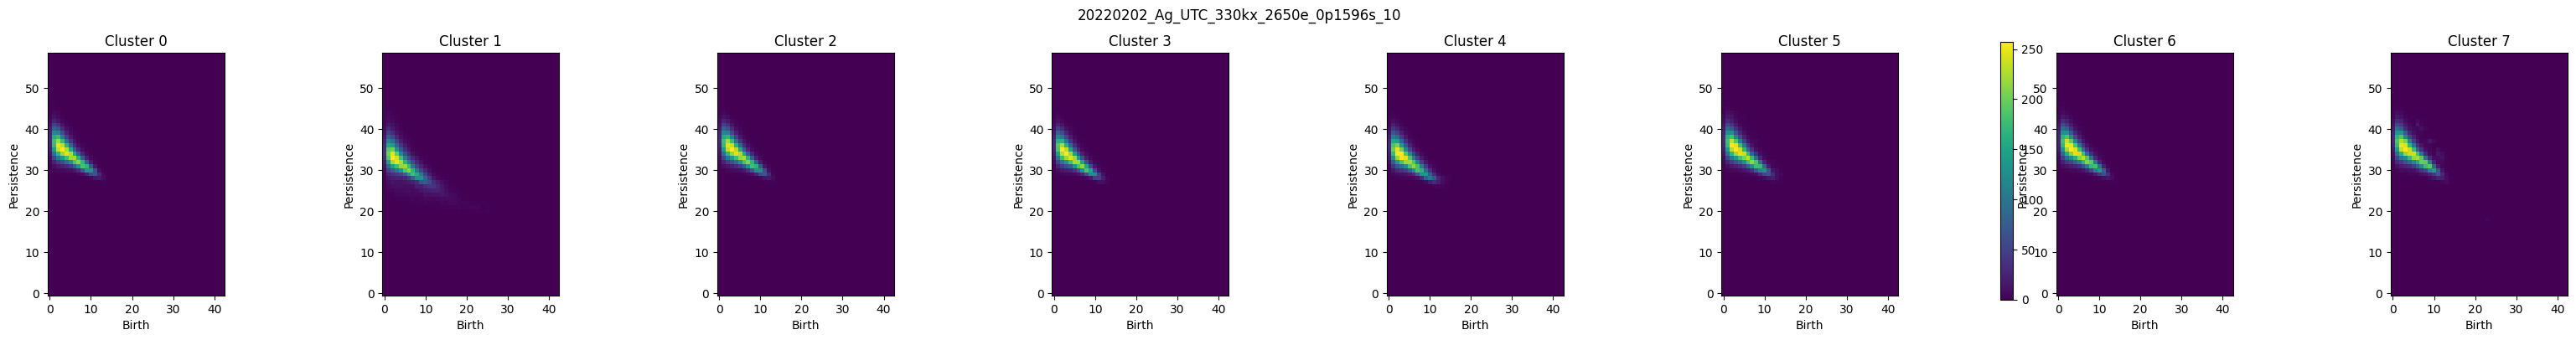

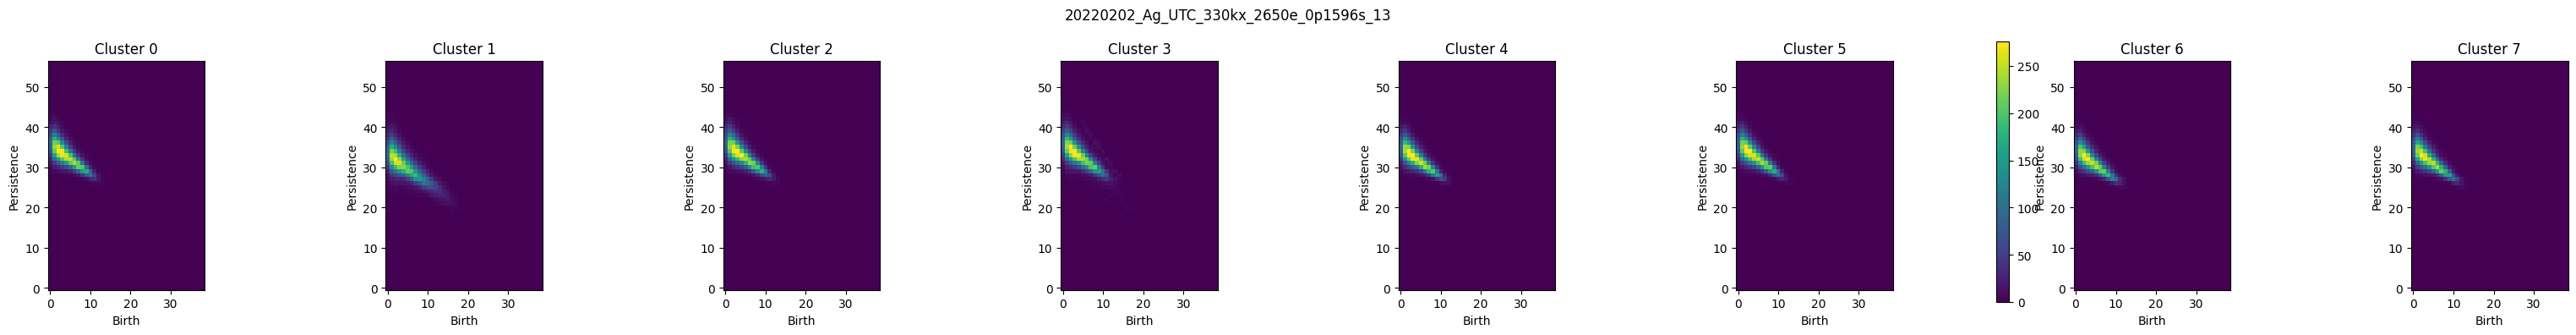

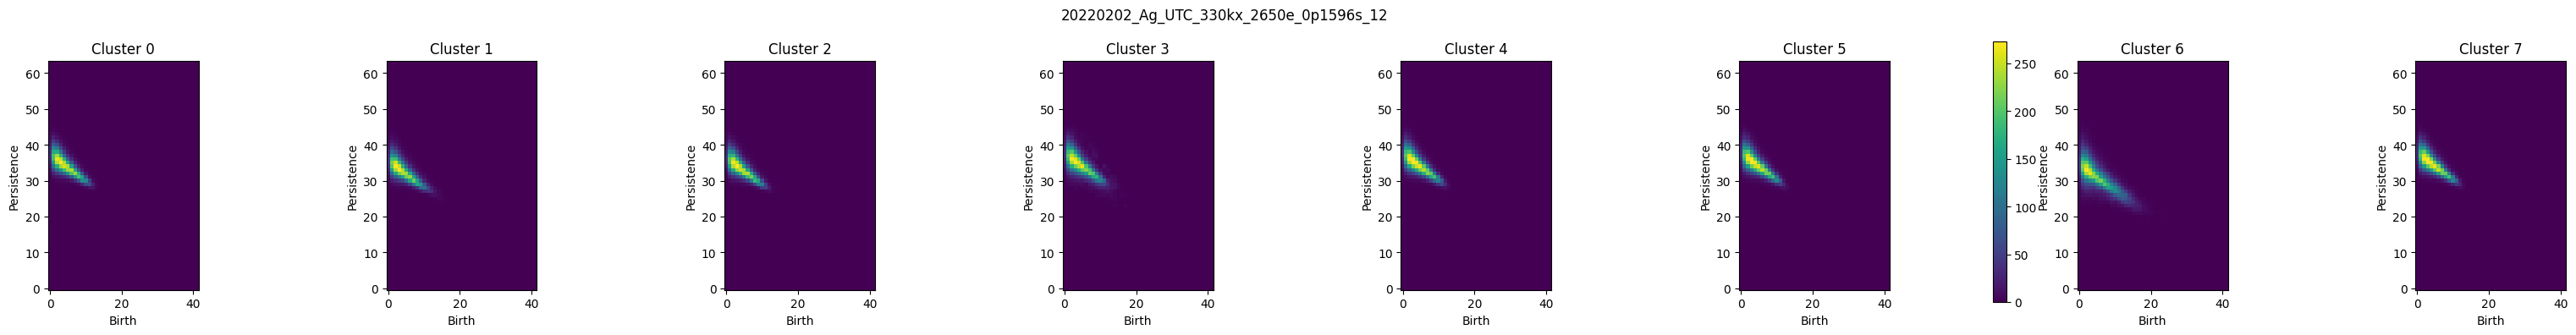

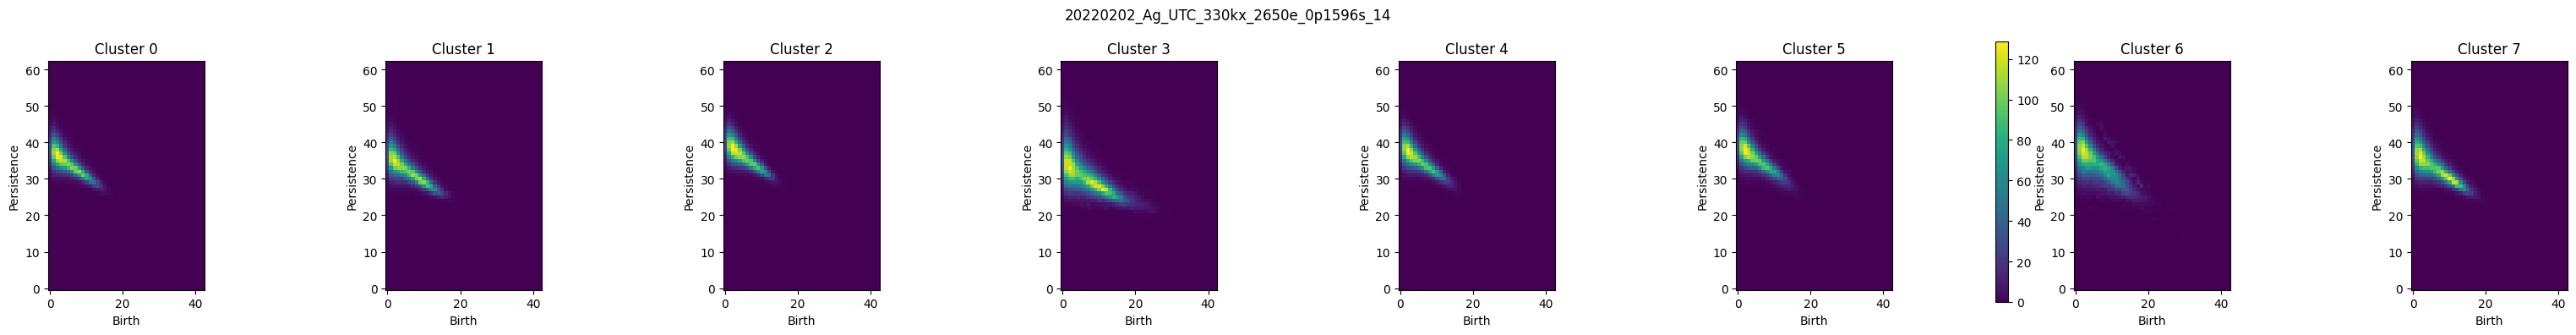

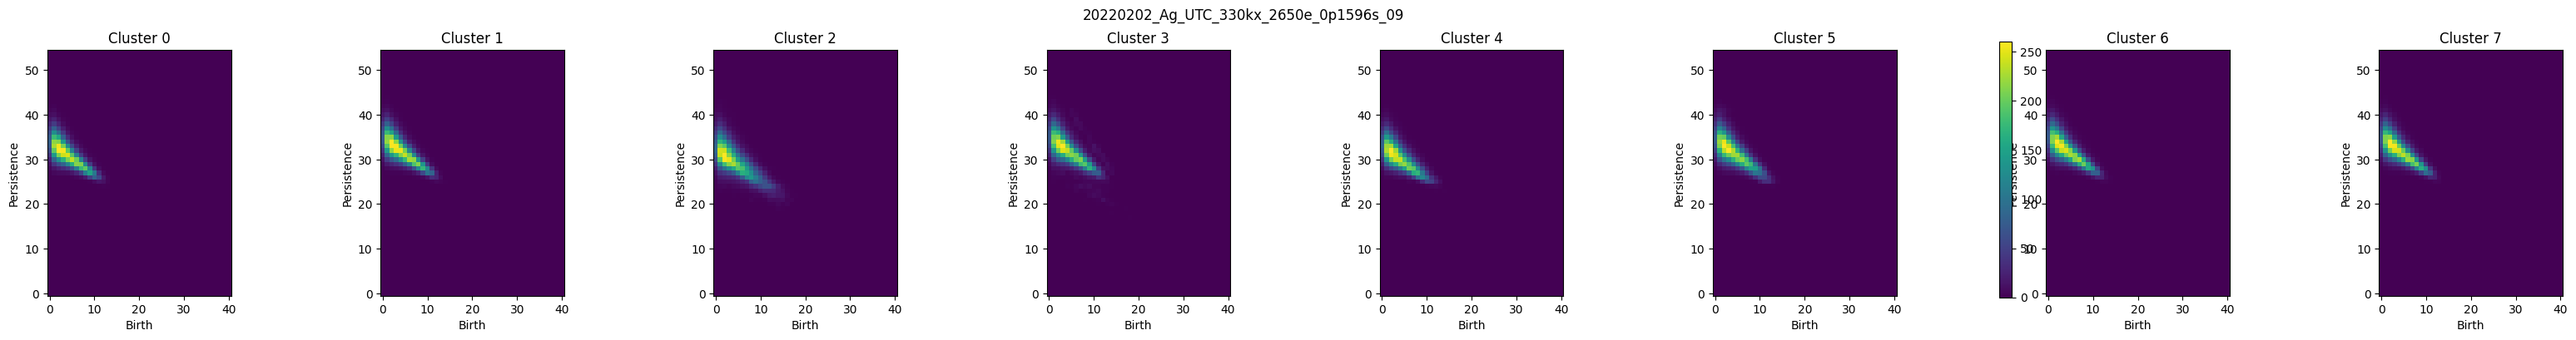

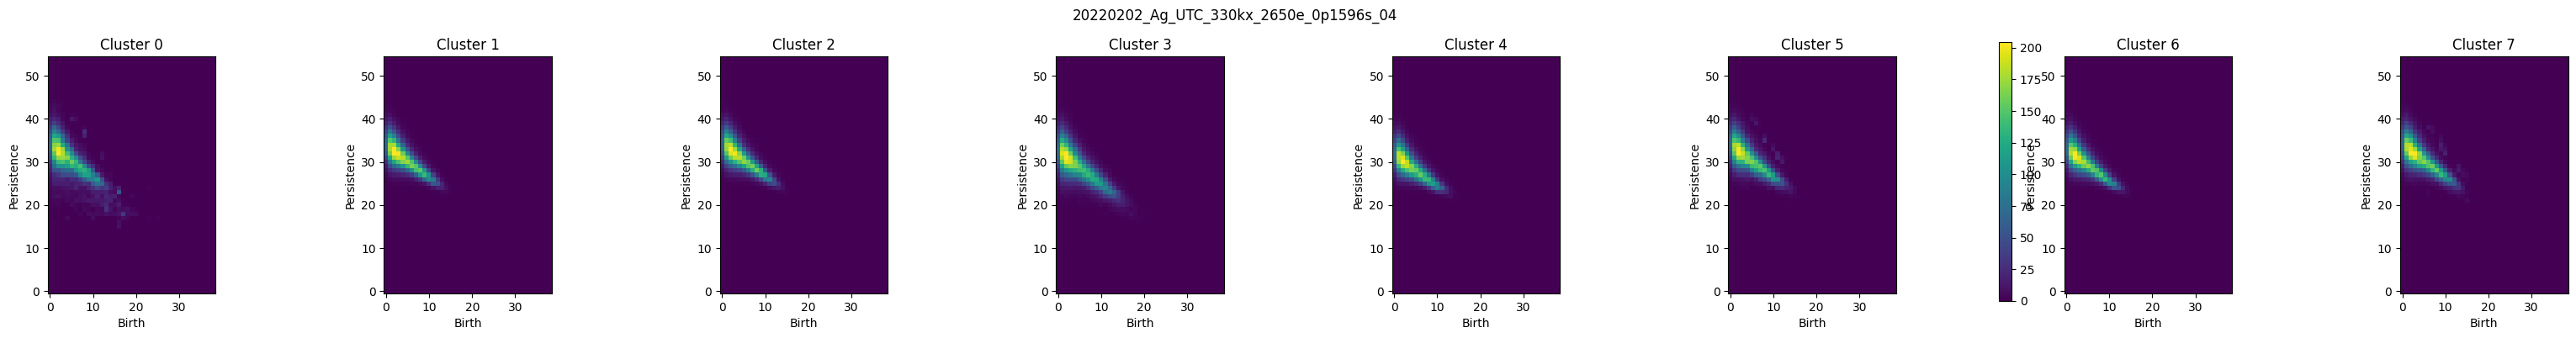

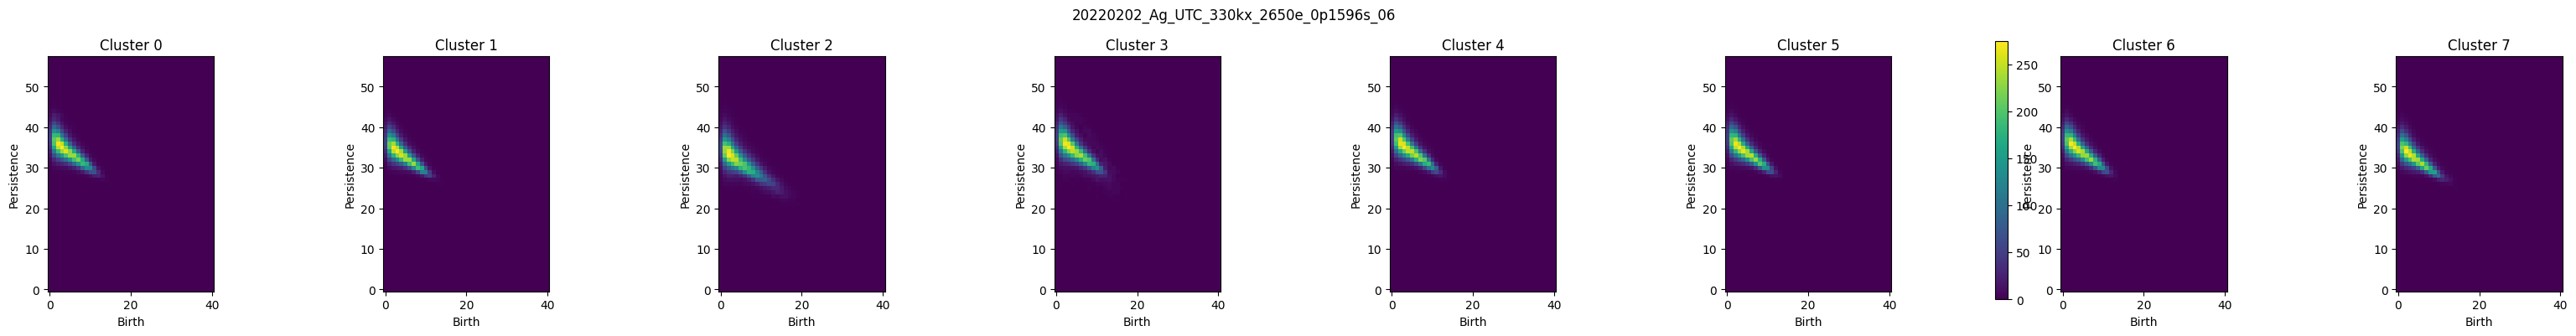

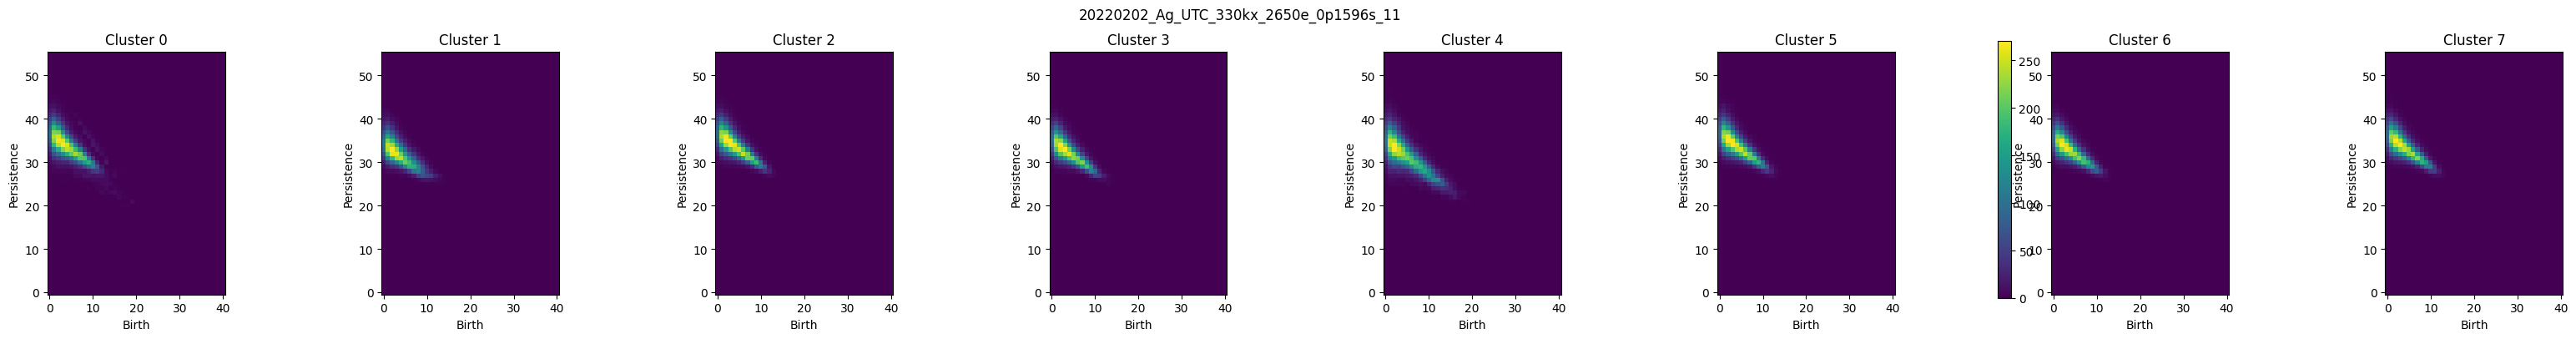

In [8]:
import matplotlib.pyplot as plt
import numpy as np

for _, row in df.iterrows():
    image_name = row["image"]
    summaries = row["cluster_summaries"]

    n_clusters = len(summaries)
    fig, axes = plt.subplots(
        1, n_clusters,
        figsize=(4 * n_clusters, 4),
        squeeze=False
    )
    axes = axes.ravel()

    for ax, (cluster, density) in zip(axes, summaries.items()):
        if density is None:
            ax.set_title(f"Cluster {cluster}\n(empty)")
            ax.axis("off")
            continue


        density = np.stack(density)

        im = ax.imshow(density, origin="lower", cmap="viridis")
        ax.set_title(f"Cluster {cluster}")
        ax.set_xlabel("Birth")
        ax.set_ylabel("Persistence")

    fig.colorbar(im, ax=axes.tolist())
    plt.suptitle(image_name)
    plt.tight_layout()
    plt.show()

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi/persistence_graphical_tools.py:150: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi/persistence_graphical_tools.py:128: UserWarning: There are 4903137 intervals given as input, whereas max_intervals is set to 1000.
  warnings.warn(
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi/persistence_graphical_tools.py:128: UserWarning: There are 1932946 intervals given as input, whereas max_intervals is set to 1000.
  warnings.warn(
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi/persistence_graphical_tools.py:128: UserWarning: There are 5427863 intervals given as input, whereas max_intervals is set to 1000.
  warnings.warn(
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi/persistence_graphical_tool

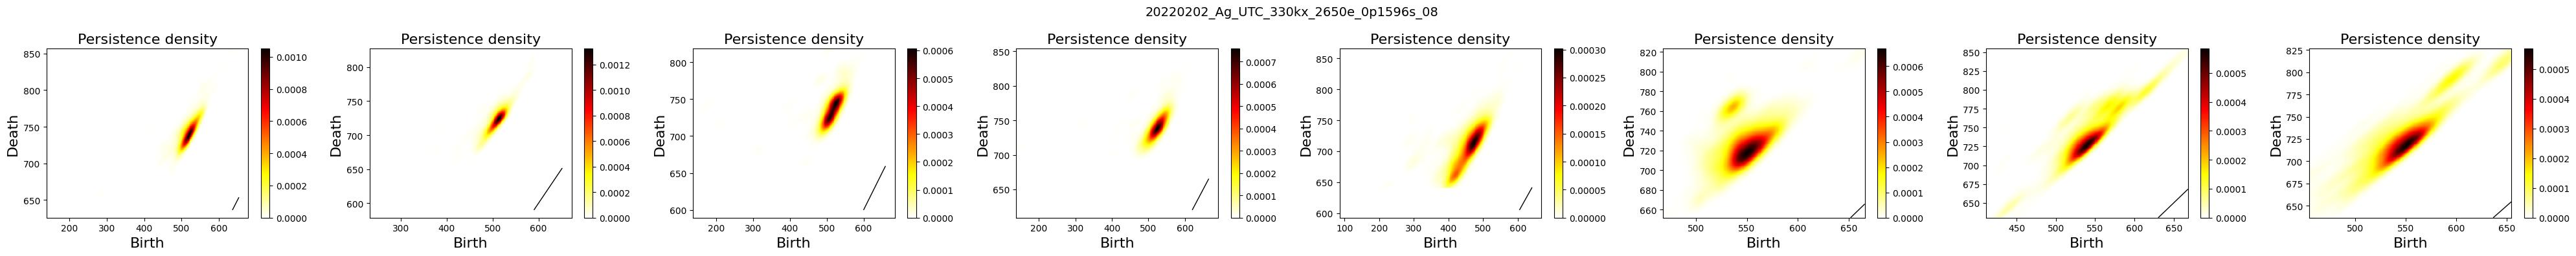

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi/persistence_graphical_tools.py:128: UserWarning: There are 314175 intervals given as input, whereas max_intervals is set to 1000.
  warnings.warn(
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi/persistence_graphical_tools.py:128: UserWarning: There are 3869864 intervals given as input, whereas max_intervals is set to 1000.
  warnings.warn(
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi/persistence_graphical_tools.py:128: UserWarning: There are 2380894 intervals given as input, whereas max_intervals is set to 1000.
  warnings.warn(
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi/persistence_graphical_tools.py:128: UserWarning: There are 2173155 intervals given as input, whereas max_intervals is set to 1000.
  warnings.warn(
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi

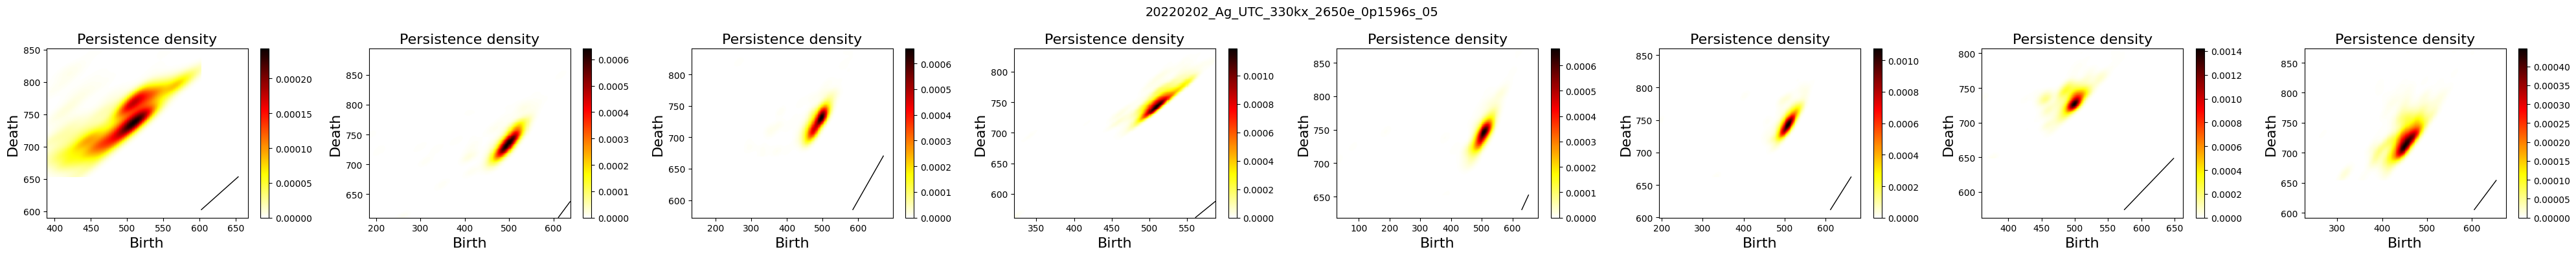

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi/persistence_graphical_tools.py:128: UserWarning: There are 323572 intervals given as input, whereas max_intervals is set to 1000.
  warnings.warn(
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi/persistence_graphical_tools.py:128: UserWarning: There are 4002715 intervals given as input, whereas max_intervals is set to 1000.
  warnings.warn(
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi/persistence_graphical_tools.py:128: UserWarning: There are 1781452 intervals given as input, whereas max_intervals is set to 1000.
  warnings.warn(
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi/persistence_graphical_tools.py:128: UserWarning: There are 271190 intervals given as input, whereas max_intervals is set to 1000.
  warnings.warn(
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi/

KeyboardInterrupt: 

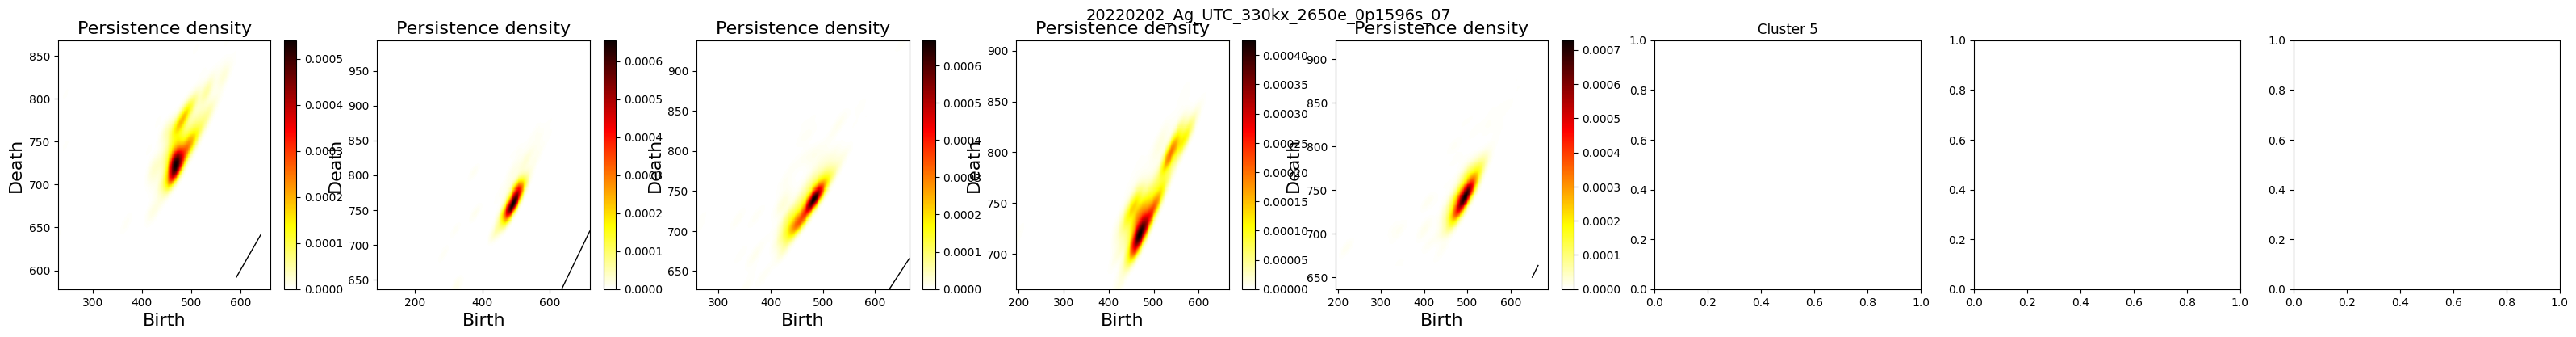

In [13]:
import gudhi
import numpy as np
import pandas as pd
import os
from pathlib import Path
from ncempy.io import dm
import matplotlib.pyplot as plt
from skimage.util import view_as_windows
from ripser import lower_star_img


def PH_patch(patched_image):
        dgms = []
        for p in patched_image:      
            dgm = lower_star_img(p)
            dgm = dgm[np.isfinite(dgm[:,1])]
            dgms.append(dgm)
        return dgms
    
def iter_patch_batches(image, patch_size=64, stride=16, batch_size=500):
    patches = []

    blocks = view_as_windows(image, (patch_size, patch_size), step=stride)
    n_rows, n_cols = blocks.shape[:2]

    for i in range(n_rows):
        for j in range(n_cols):
            patches.append(blocks[i, j])

            if len(patches) == batch_size:
                yield np.array(patches)
                patches = []

    if patches:
        yield np.array(patches)

df = pd.read_parquet("./parquets/all_images_8.parquet")

for id, row in df.iterrows():
    image_name = Path(row["image"]).stem
    matches = list(Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/").glob(f"{image_name}.dm3"))
    if not matches:
        continue
    image_path = matches[0]
    data_dict = dm.dmReader(str(Path(image_path).resolve()))
    image = data_dict['data']
    labels = row["clustered"]

    dgms = []
    for patch_batch in iter_patch_batches(image):
        dgms.extend(PH_patch(patch_batch))

    clusters = [int(i) for i in np.unique(labels)]
    cluster_dgms = {i: [] for i in clusters}
    for dgm, label in zip(dgms, labels):
        cluster_dgms[label].append(dgm)

    n_clusters = len(clusters)
    fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 4))
    if n_clusters == 1:
        axes = [axes]
    fig.suptitle(f"{image_name}", fontsize=14)

    for ax, i in zip(axes, clusters):
        ax.set_title(f"Cluster {i}")
        if not cluster_dgms[i]:
            ax.axis("off")
            continue

        all_pts = np.concatenate([
            np.array(dgm) for dgm in cluster_dgms[i] if len(dgm) > 0
        ], axis=0)

        if len(all_pts) == 0:
            ax.axis("off")
            continue

        gudhi_dgm = [(1, (float(b), float(d))) for b, d in all_pts if d > b]

        gudhi.plot_persistence_density(
            gudhi_dgm,
            axes=ax
        )

    plt.tight_layout()
    plt.show()

In [1]:
"""
Persistence Image Cluster Shape Analysis
=========================================
Pipeline:
  1. Load parquet (image × cluster_summaries)
  2. Flatten each persistence image → 1D vector
  3. Normalise per-cluster across images (remove image-level variation)
  4. UMAP embed all 104 vectors (13 images × 8 clusters)
  5. Plot: marker = cluster number, colour = source image
"""

import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from umap import UMAP
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ── 0. CONFIG ─────────────────────────────────────────────────────────────────
PARQUET_PATH = "density_analyis.parquet"   # ← change to your file path
UMAP_NEIGHBOURS = 8    # lower = more local structure; good for 104 points
UMAP_MIN_DIST   = 0.15
RANDOM_STATE    = 42

# ── 1. "LOAD ────────────────────────────────────────────────────────────────────
df = pd.read_parquet("density_analysis.parquet")
print(f"Loaded: {df.shape[0]} rows, columns: {list(df.columns)}")

# Parse cluster_summaries if stored as string
def parse_summaries(val):
    if isinstance(val, str):
        return ast.literal_eval(val)
    return val

df["cluster_summaries"] = df["cluster_summaries"].apply(parse_summaries)

# ── 2. UNPACK → flat feature matrix ───────────────────────────────────────────
records = []
for _, row in df.iterrows():
    image_name = row["image"]
    summaries  = row["cluster_summaries"]
    for cluster_id, pi_2d in summaries.items():
        flat = np.array(pi_2d).ravel().astype(float)
        records.append({
            "image":      image_name,
            "cluster":    str(cluster_id),
            "features":   flat,
        })

meta_df  = pd.DataFrame(records)[["image", "cluster"]]
features = np.vstack([r["features"] for r in records])

n_samples, n_features = features.shape
print(f"Feature matrix: {n_samples} samples × {n_features} pixels")

# ── 3. NORMALISE (remove image-level effect) ───────────────────────────────────
# Strategy: for each cluster, z-score across images so the 13 versions of
# "Cluster 0" are comparable regardless of overall brightness/scale per image.
cluster_ids  = meta_df["cluster"].values
unique_clusters = sorted(meta_df["cluster"].unique(), key=int)

features_norm = features.copy()
for c in unique_clusters:
    mask = cluster_ids == c
    cluster_feats = features[mask]                 # shape (13, n_pixels)
    # z-score each pixel across the 13 images
    mu  = cluster_feats.mean(axis=0, keepdims=True)
    std = cluster_feats.std(axis=0, keepdims=True)
    std[std == 0] = 1                              # avoid div-by-zero for dead pixels
    features_norm[mask] = (cluster_feats - mu) / std

# Global scale so UMAP distances are comparable across clusters
scaler = StandardScaler()
features_norm = scaler.fit_transform(features_norm)
print("Normalisation complete.")

# ── 4. UMAP ────────────────────────────────────────────────────────────────────
reducer = UMAP(
    n_neighbors  = UMAP_NEIGHBOURS,
    min_dist     = UMAP_MIN_DIST,
    random_state = RANDOM_STATE,
    n_components = 2,
    metric       = "euclidean",
)
embedding = reducer.fit_transform(features_norm)
print(f"UMAP embedding shape: {embedding.shape}")

meta_df["umap_x"] = embedding[:, 0]
meta_df["umap_y"] = embedding[:, 1]

# ── 5. PLOT ────────────────────────────────────────────────────────────────────
images = sorted(meta_df["image"].unique())
n_images = len(images)

# Assign a distinct colour to each image
cmap   = plt.cm.get_cmap("tab20", n_images)
im2col = {img: cmap(i) for i, img in enumerate(images)}

# Short display labels for images (last segment after last underscore chain)
def short_label(name):
    # e.g. "20220202_Ag_UTC_330kx_2650e_0p1596s_08" → "img_08"
    parts = name.split("_")
    return "img_" + parts[-1]

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

# Plot each point: coloured by image, labelled by cluster number
for _, row in meta_df.iterrows():
    colour = im2col[row["image"]]
    ax.scatter(
        row["umap_x"], row["umap_y"],
        color=colour,
        s=160, zorder=3,
        edgecolors="white", linewidths=0.4,
        alpha=0.88,
    )
    ax.text(
        row["umap_x"], row["umap_y"],
        str(row["cluster"]),
        ha="center", va="center",
        fontsize=6.5, fontweight="bold",
        color="white", zorder=4,
    )

# ── Legend: images → colours ──────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0],
           marker="o", color="none",
           markerfacecolor=im2col[img],
           markeredgecolor="white",
           markersize=9,
           label=short_label(img))
    for img in images
]
leg = ax.legend(
    handles=legend_handles,
    title="Source image",
    title_fontsize=8,
    fontsize=7,
    loc="upper left",
    framealpha=0.25,
    facecolor="#1c1f2e",
    edgecolor="#444",
    labelcolor="white",
)
leg.get_title().set_color("lightgrey")

# ── Cluster number legend (for reference) ─────────────────────────────────────
cluster_note = "  ".join([f"● {c}" for c in unique_clusters])
ax.text(
    0.5, -0.06, f"Cluster numbers:  {cluster_note}",
    transform=ax.transAxes,
    ha="center", fontsize=7.5, color="#aaaaaa",
)

ax.set_title(
    "Persistence Image Cluster Similarity  (UMAP)",
    color="white", fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("UMAP 1", color="#888888", fontsize=9)
ax.set_ylabel("UMAP 2", color="#888888", fontsize=9)
ax.tick_params(colors="#555555")
for spine in ax.spines.values():
    spine.set_edgecolor("#333333")

plt.tight_layout()
out_path = "ph_cluster_umap.png"
plt.savefig(out_path, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Saved → {out_path}")
plt.show()

# ── 6. SUMMARY TABLE ──────────────────────────────────────────────────────────
print("\n── Cluster centroid positions (UMAP) ──")
centroids = meta_df.groupby("cluster")[["umap_x","umap_y"]].mean().round(3)
print(centroids.to_string())

print("\n── Spread per cluster (std dev in UMAP space — lower = more consistent across images) ──")
spread = meta_df.groupby("cluster")[["umap_x","umap_y"]].std().round(3)
spread["total_spread"] = (spread["umap_x"]**2 + spread["umap_y"]**2).pow(0.5).round(3)
print(spread.to_string())

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: 13 rows, columns: ['image', 'cluster_summaries']


ValueError: setting an array element with a sequence.